In [2]:
#wrf_file = Dataset("E:/000_FuJian/wrfout_FuJian/A1_mp8_cu0/1wrfout_d02.nc")

In [3]:
import xarray as xr
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from wrf import uvmet, to_np, getvar, interplevel, smooth2d, get_cartopy, cartopy_xlim, cartopy_ylim, latlon_coords
import numpy as np
from netCDF4 import Dataset

In [6]:

# 用 netCDF4 包读取 WRF 模拟数据
wrf_file = Dataset("E:/000_FuJian/wrfout_FuJian/A1_mp8_cu0/1wrfout_d02.nc")
# 提取要素
lon = getvar(wrf_file, 'lon', timeidx=1)
lat = getvar(wrf_file, 'lat', timeidx=1)
u = getvar(wrf_file, 'ua', timeidx=1)
v = getvar(wrf_file, 'va', timeidx=1)
p = getvar(wrf_file, 'pressure', timeidx=1)
levels = [1000, 850, 700, 500, 300]

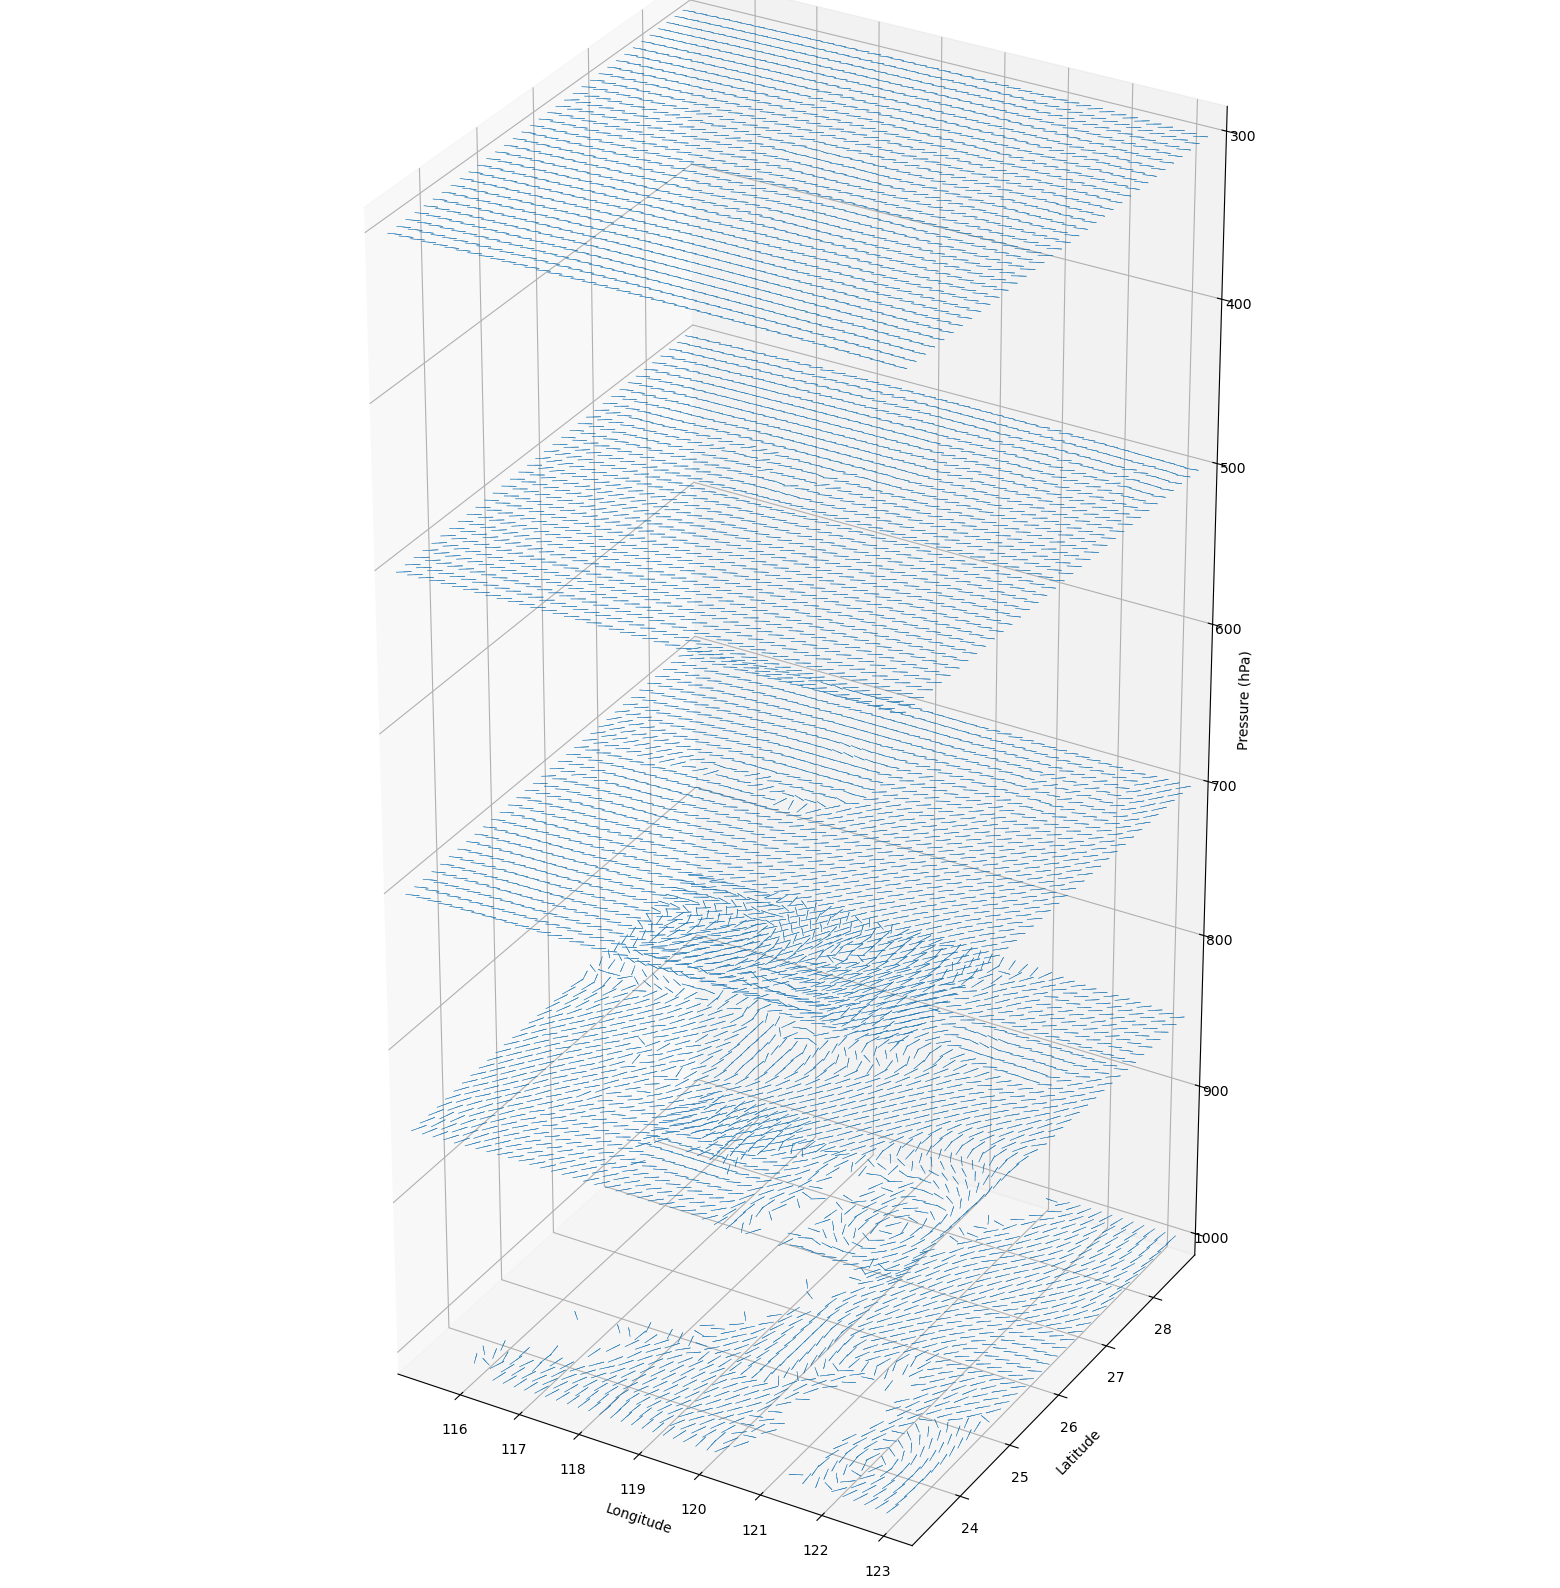

In [11]:

# 创建一个3D图形对象
fig = plt.figure(figsize=(20, 20),dpi=100)
ax = fig.add_subplot(111, projection='3d')


# 循环遍历每个层次进行绘制
for i, level in enumerate(levels):
    # 计算高度
    z = np.full((lon.shape[0], lat.shape[1]), level)


    # 提取对应层次的u和v风速数据
    u_wind = interplevel(u, p, level)
    v_wind = interplevel(v, p, level)


    # 绘制风场
    #ax.quiver(lon[::12, ::12], lat[::12, ::12], z[::12, ::12], u_wind[::12, ::12], v_wind[::12, ::12], 0, pivot="middle", length=0.5, linewidth=0.5, normalize=True, arrow_length_ratio=2)
    ax.quiver(lon[::6, ::6], lat[::6, ::6], z[::6, ::6], u_wind[::6, ::6], v_wind[::6, ::6], 0, pivot="tail", length=0.1, linewidth=0.3, normalize=True, arrow_length_ratio=2)

# 设置坐标轴范围和标签
ax.set_xlim(lon.min(), lon.max())
ax.set_ylim(lat.min(), lat.max())
ax.set_zlim(np.min(levels), np.max(levels))
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_zlabel('Pressure (hPa)')
ax.invert_zaxis()
plt.gca().set_box_aspect((1,1,2.2))
# 显示图像
plt.show()